In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
air_quality = pd.read_csv("air_quality_no2.csv", index_col= 0, parse_dates= True)
air_quality.head()
#index_col = the index (0th column set in example)
#parse_dates converts the date into timestamps

,station_antwerp,station_paris,station_london
datetime,,,
2019-05-07 02:00:00,NaN,NaN,23.0
2019-05-07 03:00:00,50.5,25.0,19.0
2019-05-07 04:00:00,45.0,27.7,19.0
2019-05-07 05:00:00,NaN,50.4,16.0
2019-05-07 06:00:00,NaN,61.9,NaN


<AxesSubplot:xlabel='datetime'>

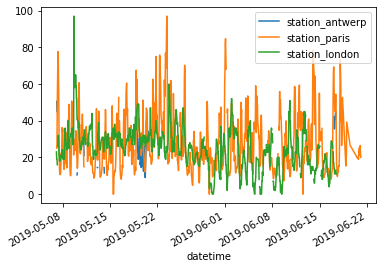

In [4]:
air_quality.plot()

<AxesSubplot:xlabel='datetime'>

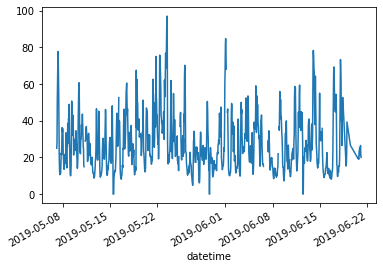

In [5]:
air_quality["station_paris"].plot()
#the air quality is the y axis and the index is the x

In [1]:
air_quality.plot.scatter(x="station_london", y="station_paris", alpha=0.5)
#scatter graph where the x and y are given

NameError: name 'air_quality' is not defined

In [ ]:
[
    method_name
    for method_name in dir(air_quality.plot)
    if not method_name.startswith("_")
]
#function to return type of possible plots

In [ ]:
air_quality.plot.box()

In [ ]:
axs= air_quality.plot.area(figsize=(12,4), subplots=True)
#if u want each column to be plotted sepeartely add the subplots=True argument to the plot function

In [ ]:
fig, axs = plt.subplots(figsize=(12, 4)) ## Create an empty matplotlib Figure and Axes
air_quality.plot.area(ax=axs) ##Use pandas to put the area plot on the prepared Figure/Axes

In [ ]:
axs.set_ylabel("NO$_2$ concentration") ## Do any matplotlib customization you like

In [ ]:
fig.savefig("no2_concentrations.png") ## Save the Figure/Axes using the existing matplotlib method.

    The .plot.* methods are applicable on both Series and DataFrames
    By default, each of the columns is plotted as a different element (line, boxplot,…)
    Any plot created by pandas is a Matplotlib object.

In [ ]:
air_quality["london_mg_per_cubic"] = air_quality["station_london"] * 1.882 #new column created using the "station_london" column
air_quality.head()

In [ ]:
air_quality["ratio_paris_antwerp"]=(air_quality["station_paris"]/ air_quality["station_antwerp"])
air_quality.head()

In [ ]:
air_quality_renamed = air_quality.rename(
    columns = {
        "station_antwerp": "BETR801",

        "station_paris": "FR04014",

        "station_london": "London Westminster",
    }
)
air_quality_renamed.head()
#rename the columns by creating  a dictionary after the rename() function.
#it can be used for rows and columns.

In [ ]:
air_quality_renamed = air_quality_renamed.rename(columns=str.lower) #makes the names all in lowercase
air_quality_renamed.head()

Create a new column by assigning the output to the DataFrame with a new column name in between the [].
Operations are element-wise, no need to loop over rows.
Use rename with a dictionary or function to rename row labels or column names.

In [ ]:
titanic = pd.read_csv("titanic.csv") #import file
titanic.head()

In [ ]:
titanic["Age"].mean() #average of ages

In [ ]:
titanic[["Age", "Fare"]].median()

The statistic applied to multiple columns of a DataFrame is calculated for each numeric column.

In [ ]:
titanic[["Age", "Fare"]].describe()

In [ ]:
titanic.agg(
    {
        "Age": ["min", "max", "median", "skew"],
        "Fare": ["min", "max", "median", "mean"],
    }
)
#specific combinations of aggregating statistics for given columns can be defined using the DataFrame.agg() method.

In [ ]:
titanic[["Sex","Age"]].groupby("Sex").mean()

the groupby() method is applied on the Sex column to make a group per category

In [ ]:
titanic.groupby("Sex").mean()

,Age,Survived
Sex,,
female,27.915709,0.742038
male,30.726645,0.188908


if we are only interested in the average age for each gender, the selection of columns (rectangular brackets [] as usual.


In [25]:
titanic.groupby(["Sex","Pclass"])["Fare"].mean()

Sex     Pclass
female  1         106.125798
        2          21.970121
        3          16.118810
male    1          67.226127
        2          19.741782
        3          12.661633
Name: Fare, dtype: float64

In [26]:
titanic["Pclass"].value_counts()
#number of passengers in each of the cabin classes

3    491
1    216
2    184
Name: Pclass, dtype: int64

In [27]:
titanic["Sex"].value_counts()

male      577
female    314
Name: Sex, dtype: int64

In [28]:
titanic.groupby("Pclass")["Pclass"].count()
#Same as above

Pclass
1    216
2    184
3    491
Name: Pclass, dtype: int64

    Aggregation statistics can be calculated on entire columns or rows
    groupby provides the power of the split-apply-combine pattern
    value_counts is a convenient shortcut to count the number of entries in each category of a variable


In [29]:
air_quality = pd.read_csv(
    "air_quality_long.csv", index_col="date.utc", parse_dates=True
)
air_quality.head()

,city,country,location,parameter,value,unit
date.utc,,,,,,
2019-06-18 06:00:00+00:00,Antwerpen,BE,BETR801,pm25,18.0,µg/m³
2019-06-17 08:00:00+00:00,Antwerpen,BE,BETR801,pm25,6.5,µg/m³
2019-06-17 07:00:00+00:00,Antwerpen,BE,BETR801,pm25,18.5,µg/m³
2019-06-17 06:00:00+00:00,Antwerpen,BE,BETR801,pm25,16.0,µg/m³
2019-06-17 05:00:00+00:00,Antwerpen,BE,BETR801,pm25,7.5,µg/m³


How to reshape the layout of tables?

In [30]:
#sort rows
titanic.sort_values(by="Age").head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
803,804,1,3,"Thomas, Master. Assad Alexander",male,0.42,0,1,2625,8.5167,NaN,C
755,756,1,2,"Hamalainen, Master. Viljo",male,0.67,1,1,250649,14.5000,NaN,S
644,645,1,3,"Baclini, Miss. Eugenie",female,0.75,2,1,2666,19.2583,NaN,C
469,470,1,3,"Baclini, Miss. Helene Barbara",female,0.75,2,1,2666,19.2583,NaN,C
78,79,1,2,"Caldwell, Master. Alden Gates",male,0.83,0,2,248738,29.0000,NaN,S


In [31]:
titanic.sort_values(by=["Pclass", "Age"], ascending=False).head()
#sort the Titanic data according to the cabin class and age in descending order.

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
851,852,0,3,"Svensson, Mr. Johan",male,74.0,0,0,347060,7.7750,NaN,S
116,117,0,3,"Connors, Mr. Patrick",male,70.5,0,0,370369,7.7500,NaN,Q
280,281,0,3,"Duane, Mr. Frank",male,65.0,0,0,336439,7.7500,NaN,Q
483,484,1,3,"Turkula, Mrs. (Hedwig)",female,63.0,0,0,4134,9.5875,NaN,S
326,327,0,3,"Nysveen, Mr. Johan Hansen",male,61.0,0,0,345364,6.2375,NaN,S


In [32]:
#filter for no2 data only
no2 = air_quality[air_quality["parameter"]=="no2"]
no2.head()

,city,country,location,parameter,value,unit
date.utc,,,,,,
2019-06-21 00:00:00+00:00,Paris,FR,FR04014,no2,20.0,µg/m³
2019-06-20 23:00:00+00:00,Paris,FR,FR04014,no2,21.8,µg/m³
2019-06-20 22:00:00+00:00,Paris,FR,FR04014,no2,26.5,µg/m³
2019-06-20 21:00:00+00:00,Paris,FR,FR04014,no2,24.9,µg/m³
2019-06-20 20:00:00+00:00,Paris,FR,FR04014,no2,21.4,µg/m³


In [33]:
PM25 = air_quality[air_quality["parameter"]=="pm25"]
PM25

,city,country,location,parameter,value,unit
date.utc,,,,,,
2019-06-18 06:00:00+00:00,Antwerpen,BE,BETR801,pm25,18.0,µg/m³
2019-06-17 08:00:00+00:00,Antwerpen,BE,BETR801,pm25,6.5,µg/m³
2019-06-17 07:00:00+00:00,Antwerpen,BE,BETR801,pm25,18.5,µg/m³
2019-06-17 06:00:00+00:00,Antwerpen,BE,BETR801,pm25,16.0,µg/m³
2019-06-17 05:00:00+00:00,Antwerpen,BE,BETR801,pm25,7.5,µg/m³
...,...,...,...,...,...,...
2019-04-09 06:00:00+00:00,London,GB,London Westminster,pm25,44.0,µg/m³
2019-04-09 05:00:00+00:00,London,GB,London Westminster,pm25,44.0,µg/m³
2019-04-09 04:00:00+00:00,London,GB,London Westminster,pm25,43.0,µg/m³


In [34]:
# use 2 measurements (head) for each location (groupby)
no2_subset = no2.sort_index().groupby(["location"]).head(2)
no2_subset

,city,country,location,parameter,value,unit
date.utc,,,,,,
2019-04-09 01:00:00+00:00,Antwerpen,BE,BETR801,no2,22.5,µg/m³
2019-04-09 01:00:00+00:00,Paris,FR,FR04014,no2,24.4,µg/m³
2019-04-09 02:00:00+00:00,London,GB,London Westminster,no2,67.0,µg/m³
2019-04-09 02:00:00+00:00,Antwerpen,BE,BETR801,no2,53.5,µg/m³
2019-04-09 02:00:00+00:00,Paris,FR,FR04014,no2,27.4,µg/m³
2019-04-09 03:00:00+00:00,London,GB,London Westminster,no2,67.0,µg/m³


In [37]:
#the values of the three stations are shown as 3 seperate columns
no2_subset.pivot(columns="location", values="value")
#The pivot() function is purely reshaping of the data: a single value for each index/column combination is required.

location,BETR801,FR04014,London Westminster
date.utc,,,
2019-04-09 01:00:00+00:00,22.5,24.4,NaN
2019-04-09 02:00:00+00:00,53.5,27.4,67.0
2019-04-09 03:00:00+00:00,NaN,NaN,67.0


<AxesSubplot:xlabel='date.utc'>

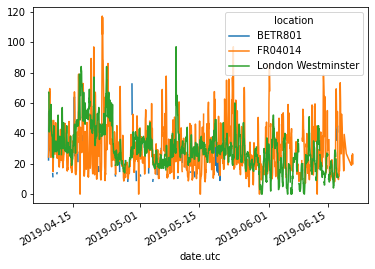

In [38]:
no2.pivot(columns="location", values="value").plot()

Pivot Table

In [35]:
#the mean concentrations for N02 and PM25 in each of the stations in table form
air_quality.pivot_table(
    values="value", index="location", columns="parameter", aggfunc="mean"
)

parameter,no2,pm25
location,,
BETR801,26.950920,23.169492
FR04014,29.374284,NaN
London Westminster,29.740050,13.443568


When multiple values need to be aggregated (in this specific case, the values on different time steps) pivot_table() can be used, providing an aggregation function (e.g. mean) on how to combine these values.

In [36]:
air_quality.pivot_table(
    values="value",
    index="location",
    columns="parameter",
    aggfunc="mean",
    margins=True
)
#when interested for the summary of the colums for each variable, also put margins = true

parameter,no2,pm25,All
location,,,
BETR801,26.950920,23.169492,24.982353
FR04014,29.374284,NaN,29.374284
London Westminster,29.740050,13.443568,21.491708
All,29.430316,14.386849,24.222743


In [40]:

#go back to the wide format table
no2_pivoted = no2.pivot(columns="location", values="value",).reset_index()
no2_pivoted.head()

location,date.utc,BETR801,FR04014,London Westminster
0,2019-04-09 01:00:00+00:00,22.5,24.4,NaN
1,2019-04-09 02:00:00+00:00,53.5,27.4,67.0
2,2019-04-09 03:00:00+00:00,54.5,34.2,67.0
3,2019-04-09 04:00:00+00:00,34.5,48.5,41.0
4,2019-04-09 05:00:00+00:00,46.5,59.5,41.0


In [42]:
#I want the air quality NO2 measurements in a single column ( long format)
no_2 = no2_pivoted.melt(id_vars="date.utc")
no_2.head()
# .melt() method converts the data from wide to long format
# this wont melt any thing mentioned in id_vars

,date.utc,location,value
0,2019-04-09 01:00:00+00:00,BETR801,22.5
1,2019-04-09 02:00:00+00:00,BETR801,53.5
2,2019-04-09 03:00:00+00:00,BETR801,54.5
3,2019-04-09 04:00:00+00:00,BETR801,34.5
4,2019-04-09 05:00:00+00:00,BETR801,46.5


In [44]:
no_2 = no2_pivoted.melt(
    id_vars="date.utc",
    value_vars=["BETR801", "FR04014", "London Westminster"],
    value_name="NO_2",
    var_name="id_location",
)
no_2.head()
#value_vars defines which columns to melt together
#value_name provides a column instead of the column name values
#var_name provides a custom column name for the column collecting the column header names

,date.utc,id_location,NO_2
0,2019-04-09 01:00:00+00:00,BETR801,22.5
1,2019-04-09 02:00:00+00:00,BETR801,53.5
2,2019-04-09 03:00:00+00:00,BETR801,54.5
3,2019-04-09 04:00:00+00:00,BETR801,34.5
4,2019-04-09 05:00:00+00:00,BETR801,46.5


    Sorting by one or more columns is supported by sort_values
    The pivot function is purely restructuring of the data, pivot_table supports aggregations
    The reverse of pivot (long to wide format) is melt (wide to long format)